In [1]:
from sympy import false

%load_ext autoreload
%autoreload 2
%cd ..

/Users/strivaud/PycharmProjects/experimental_grow


In [2]:
from tools.datasets import get_dataloaders
from gromo.containers.growing_block import (
    GrowingBlock,
    LinearGrowingBlock,
    LinearGrowingModule,
)
from gromo.containers.growing_mlp import GrowingMLP
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from tqdm.notebook import tqdm
from experiments.auxilliary_functions import *

Using default debug dir root: /Users/strivaud/PycharmProjects/experimental_grow/torch_compile_debug


In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cpu')

In [4]:
class IdDataset(torch.utils.data.Dataset):
    def __init__(self, nb_sample: int = 1, seed: int = 0, device=DEVICE):
        super(IdDataset, self).__init__()
        self.nb_sample = nb_sample
        self.seed = seed
        self.sample_index = 0
        self.device = device

    def __iter__(self):
        torch.manual_seed(self.seed)
        self.sample_index = 0
        return self

    def __next__(self):
        if self.sample_index >= self.nb_sample:
            raise StopIteration
        self.sample_index += 1
        x = torch.rand(2, device=self.device)
        return x, x

    def __len__(self):
        return self.nb_sample

    def __getitem__(self, index):
        if self.sample_index >= self.nb_sample:
            raise StopIteration
        self.sample_index += 1
        x = torch.rand(2, device=self.device)
        return x, x


class IdDataloader(torch.utils.data.DataLoader):
    def __init__(
        self, nb_sample: int = 1, batch_size: int = 100, seed: int = 0, device=DEVICE
    ):
        super(IdDataloader, self).__init__(
            IdDataset(nb_sample=nb_sample, seed=seed, device=device),
            batch_size=batch_size,
        )
        self.nb_sample = nb_sample
        self.seed = seed
        self.device = device

In [5]:
def plt_model(model, fig):
    x = torch.linspace(0, 2 * np.pi, 1000, device=DEVICE).view(-1, 1)
    y = torch.sin(x)
    y_pred = model(x)
    fig.plot(x.cpu().numpy(), y.cpu().numpy(), label="sin")
    fig.plot(x.cpu().numpy(), y_pred.cpu().detach().numpy(), label="Predicted")
    for i in range(model[0].bias.data.shape[0]):
        split = -model[0].bias.data[i] / model[0].weight.data[i, 0]
        if 0 <= split <= 2 * np.pi:
            fig.axvline(split.item(), color="black", linestyle="--")
    fig.legend()
    fig.set_xlabel("x")
    fig.yaxis.set_label_position("right")
    fig.set_ylabel("sin(x)")

In [6]:
def plt_model_id(model, fig):
    x = torch.linspace(0, 1, 1000, device=DEVICE).view(-1, 1)
    y = x
    y_pred = model(torch.cat([x, x], dim=1))
    fig.plot(x.cpu().numpy(), y.cpu().numpy(), label="selu")
    fig.plot(x.cpu().numpy(), y_pred[:, 0].cpu().detach().numpy(), label="Predicted 1")
    fig.plot(x.cpu().numpy(), y_pred[:, 1].cpu().detach().numpy(), label="Predicted 2")
    fig.legend()
    fig.set_xlabel("x")
    fig.yaxis.set_label_position("right")
    fig.set_ylabel("selu(x)")

# Hand crafted sin

This section compare a random initialization with an handcrafted one that closely match the desired result. Training from the handcrafted initialization doesn't improve performances.

In [7]:
torch.manual_seed(0)
n_neurons = 5
l1 = nn.Linear(1, n_neurons, device=DEVICE)
l2 = nn.Linear(n_neurons, 1, device=DEVICE)
net = nn.Sequential(l1, nn.ReLU(), l2)

In [8]:
batch_size = 1_000
nb_sample = 1_000
sin_train_loader, sin_val_loader, sin_test_loader, data_shape = get_dataloaders(
    dataset_name="sin", batch_size=batch_size
)

x: torch.Size([1000, 1]), y: torch.Size([1000, 1])
model: Sequential(
  (0): Linear(in_features=1, out_features=5, bias=True)
  (1): ReLU()
  (2): Linear(in_features=5, out_features=1, bias=True)
)
Initial error: 4.64e-01


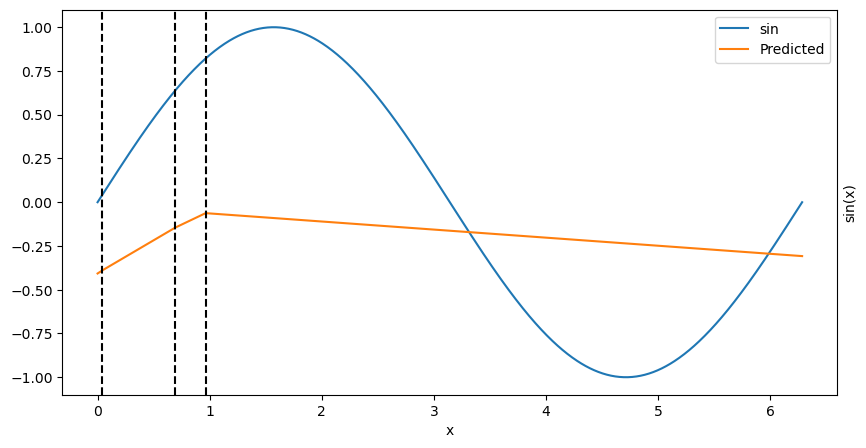

In [9]:
l2_err = evaluate_model(net, sin_train_loader, nn.MSELoss())[0]
print(f"Initial error: {l2_err:.2e}")
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plt_model(net, ax)

In [10]:
l1.weight.data = torch.ones_like(l1.weight.data)
# a = np.pi / 4
# b = 1.
a = 1.1
b = 0.87
l1.bias.data = -torch.tensor([0, a, np.pi - a, np.pi + a, 2 * np.pi - a], device=DEVICE)
l2.weight.data = torch.tensor([[b, -b, -b, b, b]], device=DEVICE)
l2.bias.data = torch.tensor([0.0], device=DEVICE)

x: torch.Size([1000, 1]), y: torch.Size([1000, 1])
model: Sequential(
  (0): Linear(in_features=1, out_features=5, bias=True)
  (1): ReLU()
  (2): Linear(in_features=5, out_features=1, bias=True)
)
Initial error: 1.05e-03


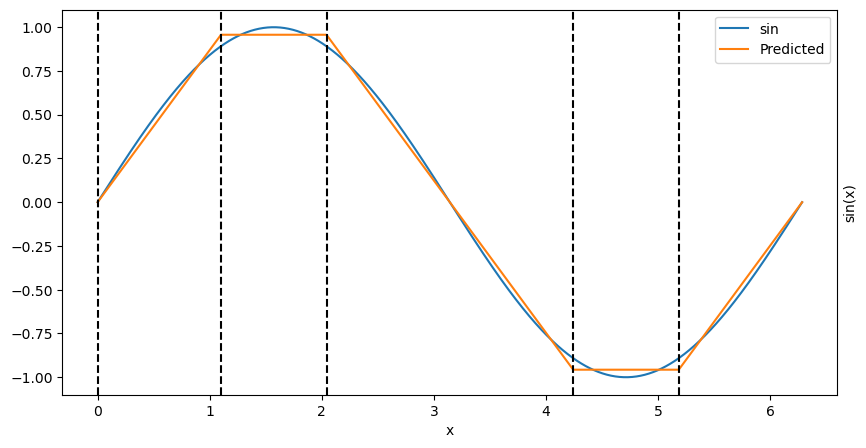

In [11]:
l2_err = evaluate_model(net, sin_test_loader, nn.MSELoss())[0]
print(f"Initial error: {l2_err:.2e}")
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plt_model(net, ax)

Train: loss=1.071e-03, accuracy=0.00, time=0.02s
x: torch.Size([1000, 1]), y: torch.Size([1000, 1])
model: Sequential(
  (0): Linear(in_features=1, out_features=5, bias=True)
  (1): ReLU()
  (2): Linear(in_features=5, out_features=1, bias=True)
)
Train: loss=1.061e-03, accuracy=0.00, time=0.01s
x: torch.Size([1000, 1]), y: torch.Size([1000, 1])
model: Sequential(
  (0): Linear(in_features=1, out_features=5, bias=True)
  (1): ReLU()
  (2): Linear(in_features=5, out_features=1, bias=True)
)
Train: loss=1.117e-03, accuracy=0.00, time=0.01s
x: torch.Size([1000, 1]), y: torch.Size([1000, 1])
model: Sequential(
  (0): Linear(in_features=1, out_features=5, bias=True)
  (1): ReLU()
  (2): Linear(in_features=5, out_features=1, bias=True)
)
Train: loss=1.090e-03, accuracy=0.00, time=0.01s
x: torch.Size([1000, 1]), y: torch.Size([1000, 1])
model: Sequential(
  (0): Linear(in_features=1, out_features=5, bias=True)
  (1): ReLU()
  (2): Linear(in_features=5, out_features=1, bias=True)
)
Train: loss=

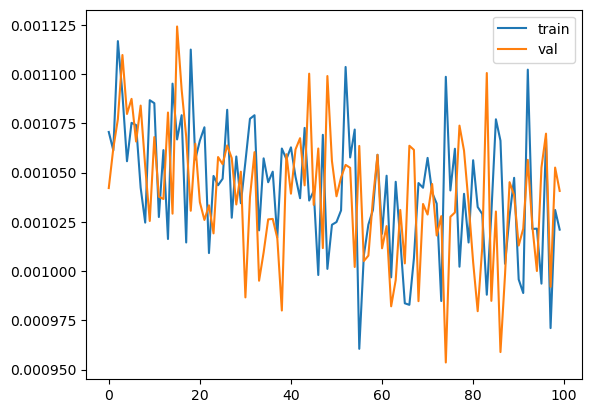

In [12]:
optimizer = torch.optim.SGD(net.parameters(), lr=1e-5, momentum=0.9)
# optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

loss_train = []
loss_val = []
for epoch in range(100):
    res = train(
        net,
        train_dataloader=sin_train_loader,
        optimizer=optimizer,
        loss_function=nn.MSELoss(),
        show=True,
    )
    loss_train.append(res[0])

    res = evaluate_model(net, sin_val_loader, nn.MSELoss())
    loss_val.append(res[0])

plt.plot(loss_train, label="train")
plt.plot(loss_val, label="val")
plt.legend()
plt.show()

x: torch.Size([1000, 1]), y: torch.Size([1000, 1])
model: Sequential(
  (0): Linear(in_features=1, out_features=5, bias=True)
  (1): ReLU()
  (2): Linear(in_features=5, out_features=1, bias=True)
)
Initial error: 9.98e-04


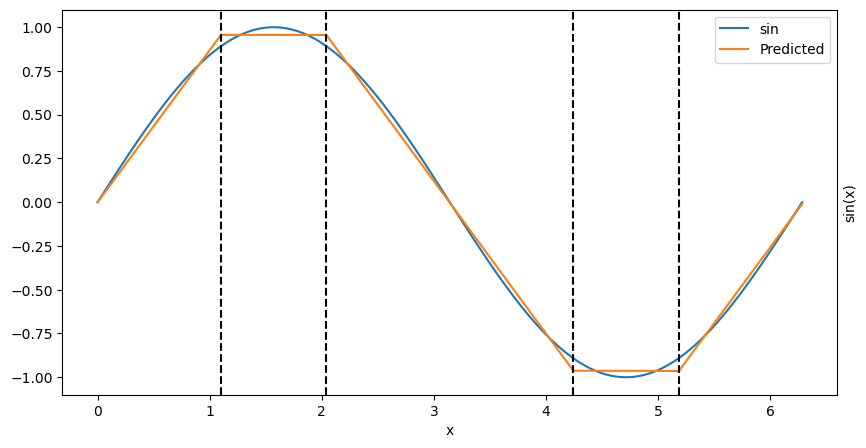

In [13]:
l2_err = evaluate_model(net, sin_val_loader, nn.MSELoss())[0]
print(f"Initial error: {l2_err:.2e}")
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plt_model(net, ax)

x: torch.Size([1000, 1]), y: torch.Size([1000, 1])
model: Sequential(
  (0): Linear(in_features=1, out_features=5, bias=True)
  (1): ReLU()
  (2): Linear(in_features=5, out_features=1, bias=True)
)
Initial error: 1.08e-03


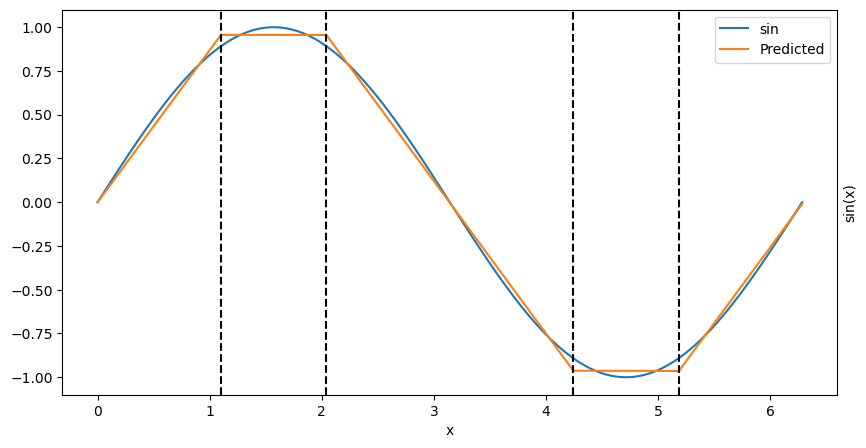

In [14]:
l2_err = evaluate_model(net, sin_train_loader, nn.MSELoss())[0]
print(f"Initial error: {l2_err:.2e}")
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plt_model(net, ax)

# Growing MLP

In [15]:
# Dataloader
batch_size = 1_000
nb_sample = 100
train_dataloader, val_dataloader, test_dataloader, data_shape = get_dataloaders(
    dataset_name="sin", batch_size=batch_size, split_train_val=0.3
)

# Model
model = GrowingMLP(
    in_features=1,
    out_features=1,
    hidden_size=10,
    number_hidden_layers=2,
    activation=nn.SELU(),
    use_bias=True,
)
print(model)

loss_func_sum = nn.MSELoss(reduction="sum")
loss_func_mean = nn.MSELoss(reduction="mean")

LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=10, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=10, out_features=10, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=10, out_features=1, use_bias=True)


x: torch.Size([1000, 1]), y: torch.Size([1000, 1])
model: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=10, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=10, out_features=10, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=10, out_features=1, use_bias=True)
layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=10, use_bias=True)
x: torch.Size([1000, 1])
x: torch.Size([1000, 10])
layer: LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=10, out_features=10, use_bias=True)
x: torch.Size([1000, 10])
x: torch.Size([1000, 10])
layer: LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=10, out_features=1, use_bias=True)
x: torch.Size([1000, 10])
x: torch.Size([1000, 1])
Loss: 1.280e+00
layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=10, use_bias=True)
x: torch.Size([1000, 1])
x: torch.Size([1000, 10])
layer: Linea

LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=10, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=10, out_features=10, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=10, out_features=1, use_bias=True)

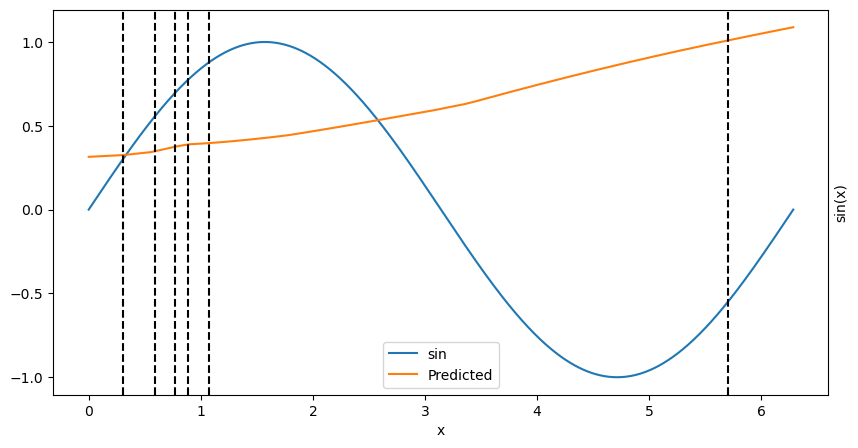

In [16]:
def plot():
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    plt_model(model, ax)


def info():
    train_dataloader, val_dataloader, test_dataloader, data_shape = get_dataloaders(
        dataset_name="sin", batch_size=batch_size, split_train_val=0.3
    )
    loss, _ = evaluate_model(
        model=model, loss_function=loss_func_mean, dataloader=test_dataloader
    )
    print(f"Loss: {loss:.3e}")
    plot()
    for lay in model.layers:
        print(lay)
        # print(lay.weight)
        print(f"Min: {lay.weight.min().item()}, Max: {lay.weight.max().item()}")
    return model


info()

layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=10, use_bias=True)
x: torch.Size([1000, 1])
x: torch.Size([1000, 10])
layer: LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=10, out_features=10, use_bias=True)
x: torch.Size([1000, 10])
x: torch.Size([1000, 10])
layer: LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=10, out_features=1, use_bias=True)
x: torch.Size([1000, 10])
x: torch.Size([1000, 1])
Initial loss: 1.251e+00
gamma n° 2: 9.495e-02 -> Loss: 1.908e-01
gamma n° 3: 1.899e-01 -> Loss: 8.245e-02
gamma n° 4: 3.798e-01 -> Loss: 1.533e+00
Selected gamma: 1.899e-01, new loss: 8.245e-02
Improvement: 1.169e+00, fo improvement: 5.005e+00


  0%|          | 0/100 [00:00<?, ?it/s]

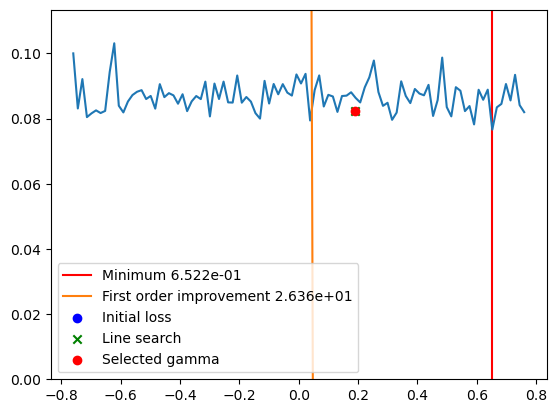

In [17]:
def step(show=True, selected_layer=None, gamma_sample: int = 100):

    initial_loss, _ = compute_statistics(
        growing_model=model, loss_function=loss_func_sum, dataloader=train_dataloader
    )
    print(f"Initial loss: {initial_loss:.3e}")

    model.compute_optimal_updates(zero_delta=False, dtype=torch.float64)
    model.reset_computation()
    if selected_layer is None:
        model.select_best_update()
    else:
        model.select_update(selected_layer)

    selected_gamma, estimated_loss, x_sup, y_sup = line_search(
        model=model,
        loss_function=loss_func_sum,
        dataloader=val_dataloader,
        initial_loss=initial_loss,
        first_order_improvement=model.currently_updated_layer.first_order_improvement,
        verbose=show,
    )
    x_sup = np.array(x_sup)
    y_sup = np.array(y_sup)
    print(f"Selected gamma: {selected_gamma:.3e}, new loss: {estimated_loss:.3e}")
    print(
        f"Improvement: {initial_loss - estimated_loss:.3e}, fo improvement: {selected_gamma * model.currently_updated_layer.first_order_improvement.item():.3e}"
    )

    if show:
        window = min(5 * selected_gamma, 2 * max(x_sup))
        x, y = full_search(
            model=model,
            loss=loss_func_sum,
            dataloader=val_dataloader,
            initial_loss=None,
            first_order_improvement=model.currently_updated_layer.first_order_improvement,
            min_value=-window,
            max_value=window,
            nb_points=gamma_sample,
        )

    model.amplitude_factor = np.sqrt(selected_gamma)

    if show:
        x_min = x[np.argmin(y)]
        plt.axvline(x_min, color="red", label=f"Minimum {x_min:.3e}")
        plt.plot(x, y)
        plt.plot(
            x,
            -x * model.currently_updated_layer.first_order_improvement.item()
            + initial_loss,
            label=f"First order improvement {model.currently_updated_layer.first_order_improvement.item():.3e}",
        )
        selected_sup = x_sup < window
        plt.scatter(0, initial_loss, color="blue", label="Initial loss")
        plt.scatter(
            x_sup[selected_sup],
            y_sup[selected_sup],
            color="green",
            label="Line search",
            marker="x",
        )
        plt.scatter(selected_gamma, estimated_loss, color="red", label="Selected gamma")
        plt.ylim(0, 1.1 * max(y))
        plt.legend()

    model.apply_change()


step(gamma_sample=100)

x: torch.Size([1000, 1]), y: torch.Size([1000, 1])
model: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=10, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=10, out_features=11, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)
layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=10, use_bias=True)
x: torch.Size([1000, 1])
x: torch.Size([1000, 10])
layer: LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=10, out_features=11, use_bias=True)
x: torch.Size([1000, 10])
x: torch.Size([1000, 11])
layer: LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)
x: torch.Size([1000, 11])
x: torch.Size([1000, 1])
Loss: 8.996e-02
layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=10, use_bias=True)
x: torch.Size([1000, 1])
x: torch.Size([1000, 10])
layer: Linea

LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=10, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=10, out_features=11, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)

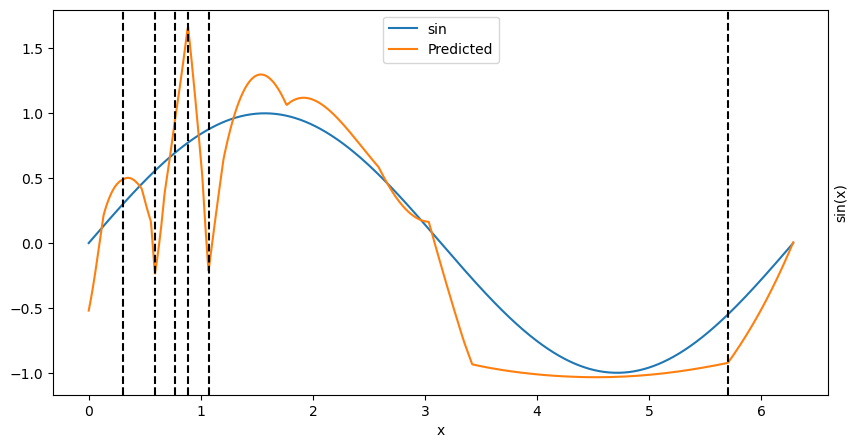

In [18]:
info()

layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=10, use_bias=True)
x: torch.Size([1000, 1])
x: torch.Size([1000, 10])
layer: LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=10, out_features=11, use_bias=True)
x: torch.Size([1000, 10])
x: torch.Size([1000, 11])
layer: LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)
x: torch.Size([1000, 11])
x: torch.Size([1000, 1])
Initial loss: 9.071e-02
gamma n° 2: 1.947e-05 -> Loss: 5.186e-02
gamma n° 3: 3.893e-05 -> Loss: 2.577e-01
Selected gamma: 1.947e-05, new loss: 5.186e-02
Improvement: 3.885e-02, fo improvement: 1.814e-01


  0%|          | 0/100 [00:00<?, ?it/s]

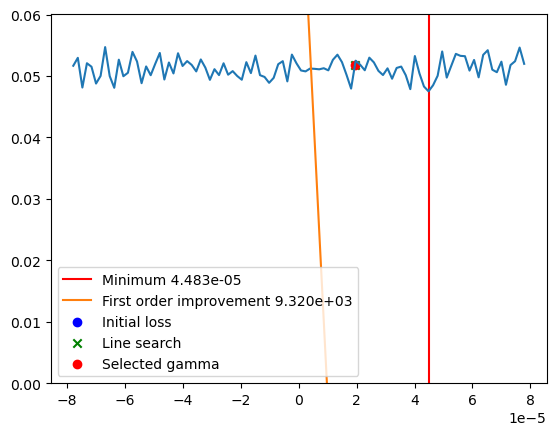

In [19]:
step()

x: torch.Size([1000, 1]), y: torch.Size([1000, 1])
model: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=12, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=12, out_features=11, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)
layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=12, use_bias=True)
x: torch.Size([1000, 1])
x: torch.Size([1000, 12])
layer: LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=12, out_features=11, use_bias=True)
x: torch.Size([1000, 12])
x: torch.Size([1000, 11])
layer: LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)
x: torch.Size([1000, 11])
x: torch.Size([1000, 1])
Loss: 5.143e-02
layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=12, use_bias=True)
x: torch.Size([1000, 1])
x: torch.Size([1000, 12])
layer: Linea

LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=12, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=12, out_features=11, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)

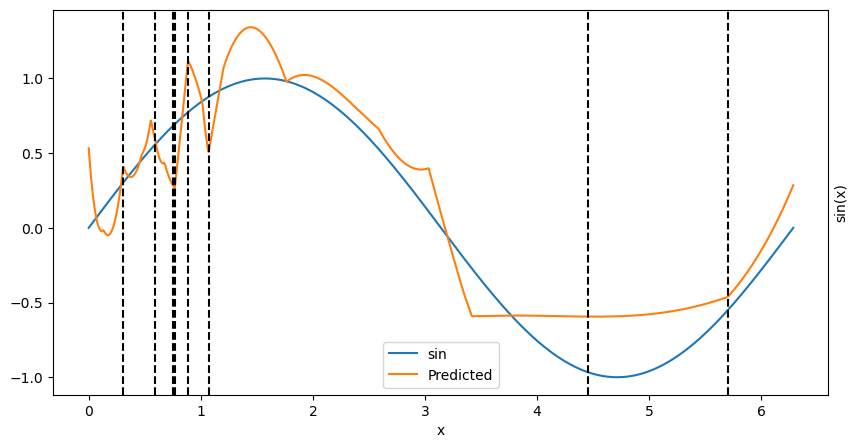

In [20]:
info()

In [21]:
model.normalise()

x: torch.Size([1000, 1]), y: torch.Size([1000, 1])
model: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=12, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=12, out_features=11, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)
layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=12, use_bias=True)
x: torch.Size([1000, 1])
x: torch.Size([1000, 12])
layer: LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=12, out_features=11, use_bias=True)
x: torch.Size([1000, 12])
x: torch.Size([1000, 11])
layer: LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)
x: torch.Size([1000, 11])
x: torch.Size([1000, 1])
Loss: 5.119e+02
layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=12, use_bias=True)
x: torch.Size([1000, 1])
x: torch.Size([1000, 12])
layer: Linea

LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=12, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=12, out_features=11, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)

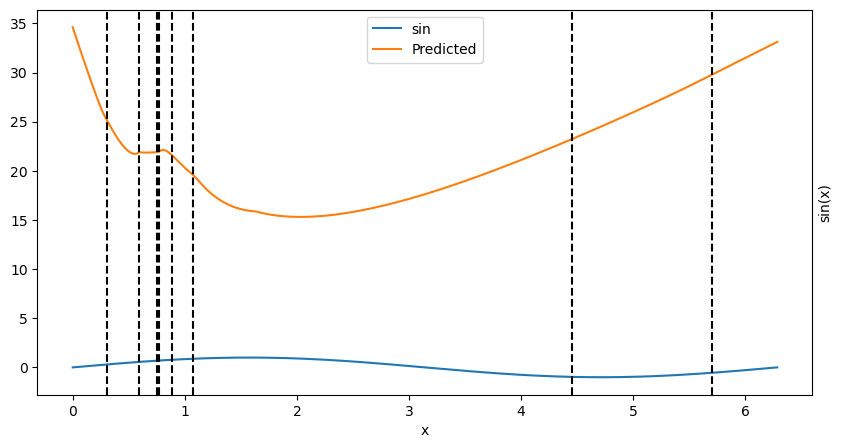

In [22]:
info()

layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=12, use_bias=True)
x: torch.Size([1000, 1])
x: torch.Size([1000, 12])
layer: LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=12, out_features=11, use_bias=True)
x: torch.Size([1000, 12])
x: torch.Size([1000, 11])
layer: LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)
x: torch.Size([1000, 11])
x: torch.Size([1000, 1])
Initial loss: 5.015e+02
gamma n° 2: 1.410e-04 -> Loss: 6.510e+01
gamma n° 3: 2.819e-04 -> Loss: 8.464e+01
Selected gamma: 1.410e-04, new loss: 6.510e+01
Improvement: 4.364e+02, fo improvement: 1.003e+03


  0%|          | 0/100 [00:00<?, ?it/s]

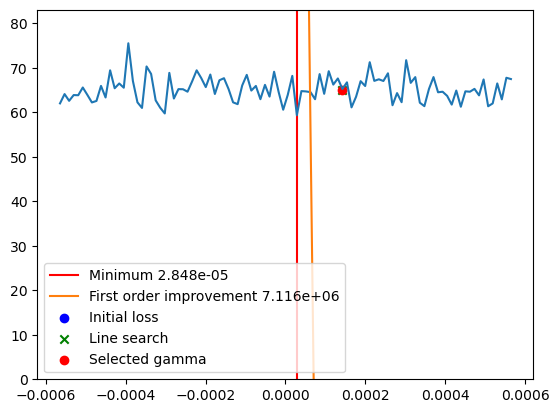

In [23]:
step()

x: torch.Size([1000, 1]), y: torch.Size([1000, 1])
model: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=14, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=14, out_features=11, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)
layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=14, use_bias=True)
x: torch.Size([1000, 1])
x: torch.Size([1000, 14])
layer: LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=14, out_features=11, use_bias=True)
x: torch.Size([1000, 14])
x: torch.Size([1000, 11])
layer: LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)
x: torch.Size([1000, 11])
x: torch.Size([1000, 1])
Loss: 5.786e+01
layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=14, use_bias=True)
x: torch.Size([1000, 1])
x: torch.Size([1000, 14])
layer: Linea

LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=14, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=14, out_features=11, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)

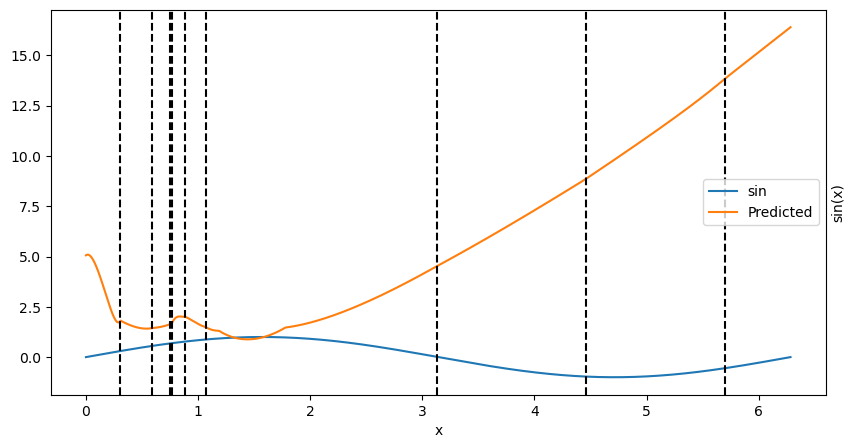

In [24]:
info()

layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=14, use_bias=True)
x: torch.Size([1000, 1])
x: torch.Size([1000, 14])
layer: LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=14, out_features=11, use_bias=True)
x: torch.Size([1000, 14])
x: torch.Size([1000, 11])
layer: LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)
x: torch.Size([1000, 11])
x: torch.Size([1000, 1])
Initial loss: 6.087e+01
gamma n° 2: 1.777e-04 -> Loss: 6.794e+00
gamma n° 3: 3.554e-04 -> Loss: 1.293e+01
Selected gamma: 1.777e-04, new loss: 6.794e+00
Improvement: 5.408e+01, fo improvement: 1.217e+02


  0%|          | 0/100 [00:00<?, ?it/s]

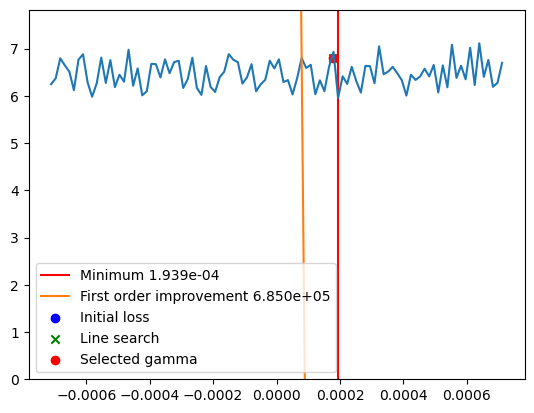

In [25]:
step()

x: torch.Size([1000, 1]), y: torch.Size([1000, 1])
model: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=16, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=16, out_features=11, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)
layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=16, use_bias=True)
x: torch.Size([1000, 1])
x: torch.Size([1000, 16])
layer: LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=16, out_features=11, use_bias=True)
x: torch.Size([1000, 16])
x: torch.Size([1000, 11])
layer: LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)
x: torch.Size([1000, 11])
x: torch.Size([1000, 1])
Loss: 6.273e+00
layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=16, use_bias=True)
x: torch.Size([1000, 1])
x: torch.Size([1000, 16])
layer: Linea

LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=16, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=16, out_features=11, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)

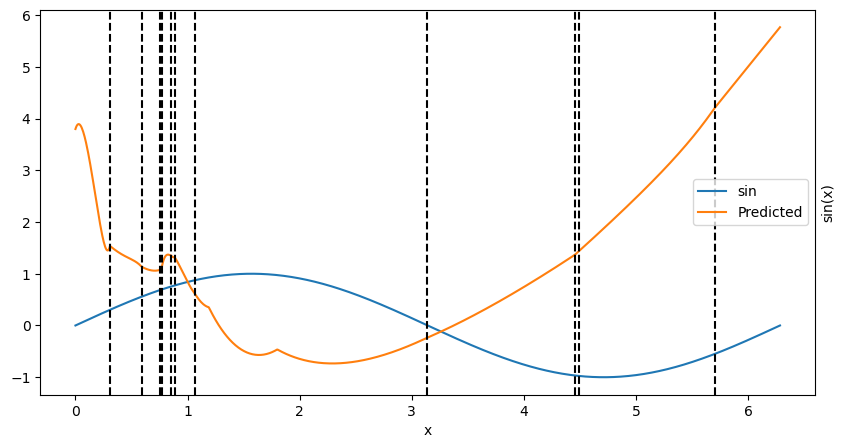

In [26]:
info()

model.normalise()

x: torch.Size([1000, 1]), y: torch.Size([1000, 1])
model: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=16, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=16, out_features=11, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)
layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=16, use_bias=True)
x: torch.Size([1000, 1])
x: torch.Size([1000, 16])
layer: LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=16, out_features=11, use_bias=True)
x: torch.Size([1000, 16])
x: torch.Size([1000, 11])
layer: LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)
x: torch.Size([1000, 11])
x: torch.Size([1000, 1])
Loss: 6.730e+00
layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=16, use_bias=True)
x: torch.Size([1000, 1])
x: torch.Size([1000, 16])
layer: Linea

LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=16, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=16, out_features=11, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)

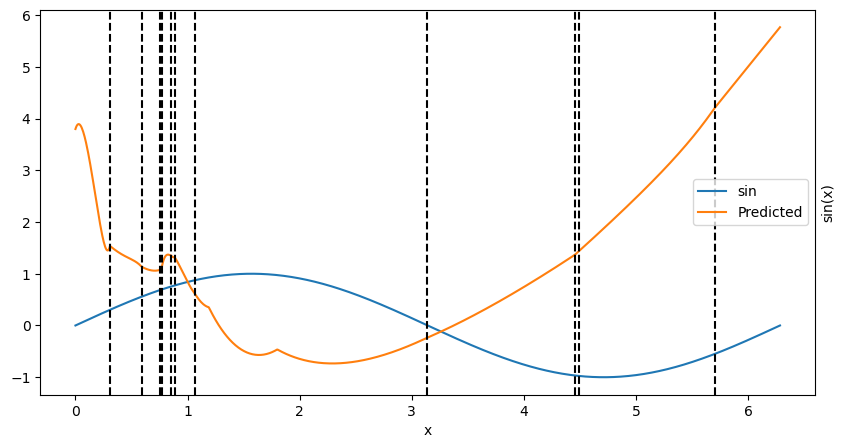

In [27]:
info()

In [28]:
torch.save(model, "model.pt")

layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=16, use_bias=True)
x: torch.Size([1000, 1])
x: torch.Size([1000, 16])
layer: LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=16, out_features=11, use_bias=True)
x: torch.Size([1000, 16])
x: torch.Size([1000, 11])
layer: LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)
x: torch.Size([1000, 11])
x: torch.Size([1000, 1])
Train: loss=6.604e+00, accuracy=0.00, time=0.01s
x: torch.Size([1000, 1]), y: torch.Size([1000, 1])
model: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=16, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=16, out_features=11, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)
layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=16, use_bias=True)
x: torch.Size([1000, 1])
x: to

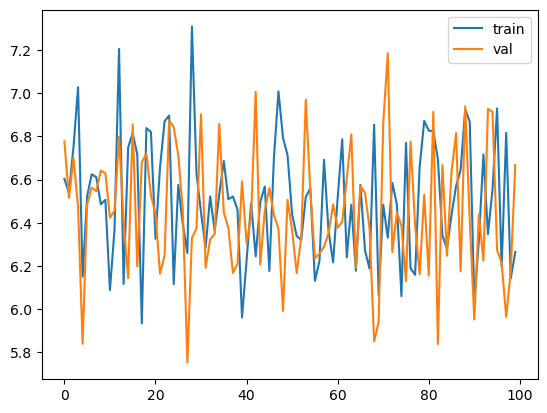

In [29]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.0, momentum=0.9)
loss_train = []
loss_val = []
for epoch in range(100):
    res = train(
        model,
        train_dataloader=sin_train_loader,
        optimizer=optimizer,
        loss_function=nn.MSELoss(),
        show=True,
    )
    loss_train.append(res[0])
    res = evaluate_model(model, sin_val_loader, nn.MSELoss())
    loss_val.append(res[0])

plt.plot(loss_train, label="train")
plt.plot(loss_val, label="val")
plt.legend()
plt.show()

x: torch.Size([1000, 1]), y: torch.Size([1000, 1])
model: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=16, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=16, out_features=11, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)
layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=16, use_bias=True)
x: torch.Size([1000, 1])
x: torch.Size([1000, 16])
layer: LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=16, out_features=11, use_bias=True)
x: torch.Size([1000, 16])
x: torch.Size([1000, 11])
layer: LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)
x: torch.Size([1000, 11])
x: torch.Size([1000, 1])
Loss: 6.950e+00
layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=16, use_bias=True)
x: torch.Size([1000, 1])
x: torch.Size([1000, 16])
layer: Linea

LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=16, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=16, out_features=11, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=11, out_features=1, use_bias=True)

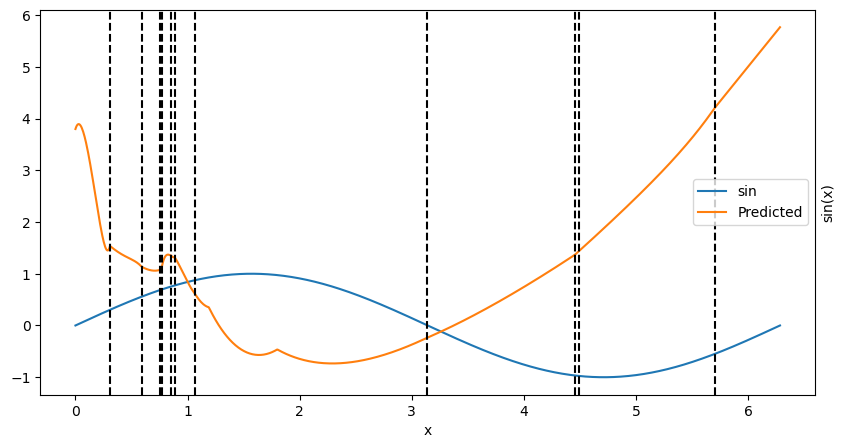

In [30]:
info()

In [31]:
model.weights_statistics()

{0: {'weight': {'min': -21.296672821044922,
   'max': 19.384119033813477,
   'mean': 0.47946423292160034,
   'std': 11.748860359191895},
  'bias': {'min': -19.80938720703125,
   'max': 17.237415313720703,
   'mean': -2.7803096771240234,
   'std': 9.835399627685547},
  'input_shape': 1,
  'output_shape': 16},
 1: {'weight': {'min': -21.296672821044922,
   'max': 18.708789825439453,
   'mean': -0.12314245849847794,
   'std': 2.444493532180786},
  'bias': {'min': -15.286388397216797,
   'max': 1.2271509170532227,
   'mean': -1.3964471817016602,
   'std': 4.650711536407471},
  'input_shape': 16,
  'output_shape': 11},
 2: {'weight': {'min': -11.7989501953125,
   'max': 21.296672821044922,
   'mean': 2.4694368839263916,
   'std': 10.795084953308105},
  'bias': {'min': 58.61223602294922,
   'max': 58.61223602294922,
   'mean': 58.61223602294922,
   'std': -1},
  'input_shape': 11,
  'output_shape': 1}}

# Only adding neurons

In [46]:
batch_size = 1_000
nb_sample = 1000

model = GrowingMLP(
    in_features=2,
    out_features=2,
    number_hidden_layers=1,
    hidden_size=1,
    activation=nn.ReLU(),
    use_bias=True,
)
print(model)

loss_func_sum = nn.MSELoss(reduction="sum")
loss_func_mean = nn.MSELoss(reduction="mean")

LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=2, out_features=1, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=1, out_features=2, use_bias=True)


In [47]:
def plot():
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    plt_model_id(model, ax)

In [48]:
def info():
    loss, _ = evaluate_model(
        model=model,
        dataloader=IdDataloader(nb_sample=nb_sample, batch_size=batch_size),
        loss_function=loss_func_mean,
    )
    print(f"Loss: {loss:.3e}")
    plot()
    for lay in model.layers:
        print(lay)
        # print(lay.weight)
        print(f"Min: {lay.weight.min().item()}, Max: {lay.weight.max().item()}")
    return model

In [49]:
def step(show=True, selected_layer=None):
    train_dataloader = IdDataloader(nb_sample=nb_sample, batch_size=batch_size)

    initial_loss, _ = compute_statistics(
        growing_model=model, loss_function=loss_func_sum, dataloader=train_dataloader
    )

    print(f"Initial loss: {initial_loss:.3e}")

    model.compute_optimal_updates(zero_delta=True)
    model.reset_computation()
    if selected_layer is None:
        model.select_best_update()
    else:
        model.select_update(selected_layer, verbose=show)
    # model.currently_updated_layer.delete_update()

    selected_gamma, estimated_loss, x_sup, y_sup = line_search(
        model=model,
        loss_function=loss_func_sum,
        dataloader=IdDataloader(nb_sample=nb_sample, batch_size=batch_size),
        initial_loss=initial_loss,
        first_order_improvement=model.currently_updated_layer.first_order_improvement,
        verbose=show,
    )
    x_sup = np.array(x_sup)
    y_sup = np.array(y_sup)
    print(f"Selected gamma: {selected_gamma:.3e}, new loss: {estimated_loss:.3e}")
    print(
        f"Improvement: {initial_loss - estimated_loss:.3e}, fo improvement: {selected_gamma * model.currently_updated_layer.first_order_improvement.item():.3e}"
    )

    if show:
        window = 5 * selected_gamma
        x, y = full_search(
            model=model,
            loss=loss_func_sum,
            dataloader=IdDataloader(nb_sample=nb_sample, batch_size=batch_size),
            initial_loss=None,
            first_order_improvement=model.currently_updated_layer.first_order_improvement,
            min_value=-window,
            max_value=window,
        )

    model.amplitude_factor = np.sqrt(selected_gamma)

    if show:
        x_min = x[np.argmin(y)]
        plt.axvline(x_min, color="red", label=f"Minimum {x_min:.3e}")
        plt.plot(x, y)
        plt.plot(
            x,
            -x * model.currently_updated_layer.first_order_improvement.item()
            + initial_loss,
            label=f"First order improvement {model.currently_updated_layer.first_order_improvement.item():.3e}",
        )
        selected_sup = x_sup < window
        plt.scatter(
            x_sup[selected_sup],
            y_sup[selected_sup],
            color="green",
            label="Line search",
            marker="x",
        )
        plt.scatter(selected_gamma, estimated_loss, color="red", label="Selected gamma")
        plt.ylim(0, 1.1 * max(y))
        plt.legend()

    model.apply_change()

In [50]:
model.layers[0].weight = nn.Parameter(
    torch.tensor([[1.0, 0.0], [0.0, 1.0]], device=DEVICE)
)
model.layers[1].weight = nn.Parameter(
    torch.tensor([[1.0, 0.0], [0.0, 1.0]], device=DEVICE)
)

x: torch.Size([1000, 2]), y: torch.Size([1000, 2])
model: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=2, out_features=1, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=1, out_features=2, use_bias=True)
layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=2, out_features=1, use_bias=True)
x: torch.Size([1000, 2])
x: torch.Size([1000, 2])
layer: LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=1, out_features=2, use_bias=True)
x: torch.Size([1000, 2])
x: torch.Size([1000, 2])
Loss: 5.964e-01
layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=2, out_features=1, use_bias=True)
x: torch.Size([1000, 2])
x: torch.Size([1000, 2])
layer: LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=1, out_features=2, use_bias=True)
x: torch.Size([1000, 2])
x: torch.Size([1000, 2])
LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=2, out_features=1, use_bias=True)
Min: 0.0, Max: 1.0
LinearG

LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=2, out_features=1, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=1, out_features=2, use_bias=True)

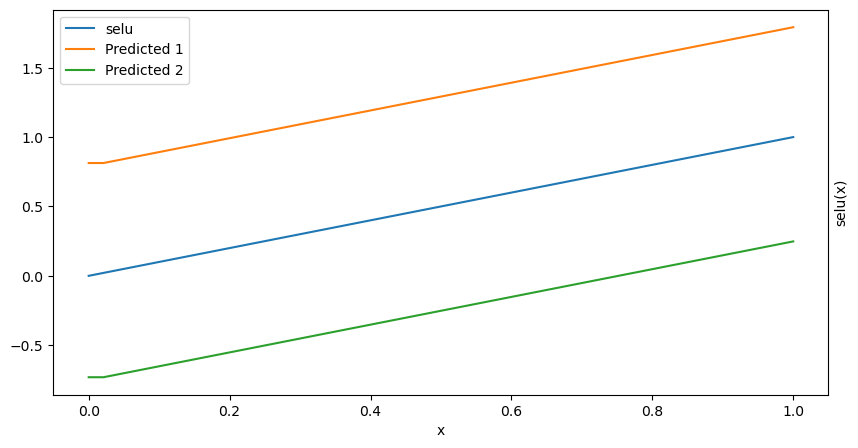

In [51]:
info()

In [44]:
model.layers[0].weight = nn.Parameter(torch.tensor([[1.0, 0.0]], device=DEVICE))
model.layers[1].weight = nn.Parameter(torch.tensor([[1.0], [0.0]], device=DEVICE))

In [45]:
info()

x: torch.Size([1000, 2]), y: torch.Size([1000, 2])
model: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=2, out_features=2, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=2, out_features=2, use_bias=True)
layer: LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=2, out_features=2, use_bias=True)
x: torch.Size([1000, 2])


RuntimeError: The expanded size of the tensor (1) must match the existing size (2) at non-singleton dimension 1.  Target sizes: [1000, 1].  Tensor sizes: [2]

Initial loss: 3.330e-01
gamma n° 2: 3.190e-01 -> Loss: 5.057e-02
gamma n° 3: 6.380e-01 -> Loss: 0.000e+00
gamma n° 4: 1.276e+00 -> Loss: 0.000e+00
Selected gamma: 6.380e-01, new loss: 0.000e+00
Improvement: 3.330e-01, fo improvement: 1.332e+00


  0%|          | 0/100 [00:00<?, ?it/s]

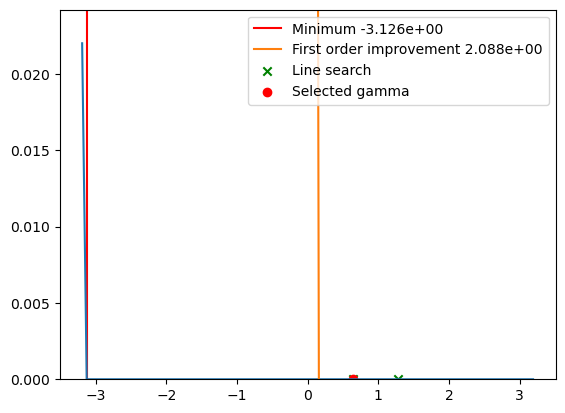

In [47]:
step()

Loss: 1.243e-02
LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=2, out_features=2, use_bias=False)
Min: 0.0, Max: 1.4870471954345703
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=2, out_features=2, use_bias=False)
Min: 0.0, Max: 1.0


LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=2, out_features=2, use_bias=False)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=2, out_features=2, use_bias=False)

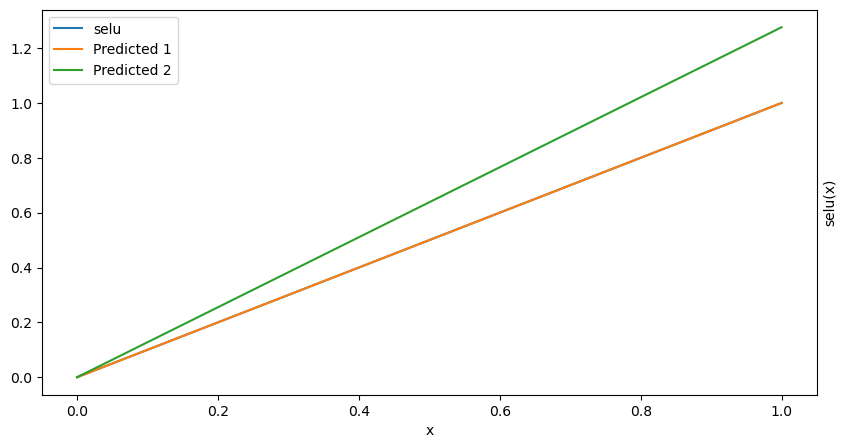

In [48]:
info()

Initial loss: 2.128e-02
gamma n° 2: 2.500e-01 -> Loss: 7.629e-03
gamma n° 3: 5.000e-01 -> Loss: 0.000e+00
gamma n° 4: 1.000e+00 -> Loss: 0.000e+00
Selected gamma: 5.000e-01, new loss: 0.000e+00
Improvement: 2.128e-02, fo improvement: 8.511e-02


  0%|          | 0/100 [00:00<?, ?it/s]

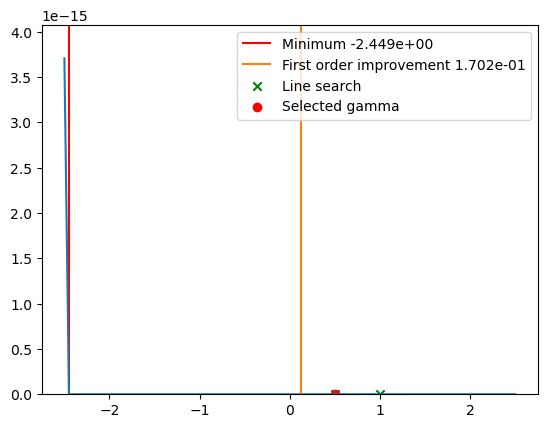

In [49]:
step()

Loss: 2.322e-15
LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=2, out_features=3, use_bias=False)
Min: -1.1879580341656037e-07, Max: 1.4870471954345703
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=3, out_features=2, use_bias=False)
Min: -0.3819214999675751, Max: 1.0


LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=2, out_features=3, use_bias=False)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=3, out_features=2, use_bias=False)

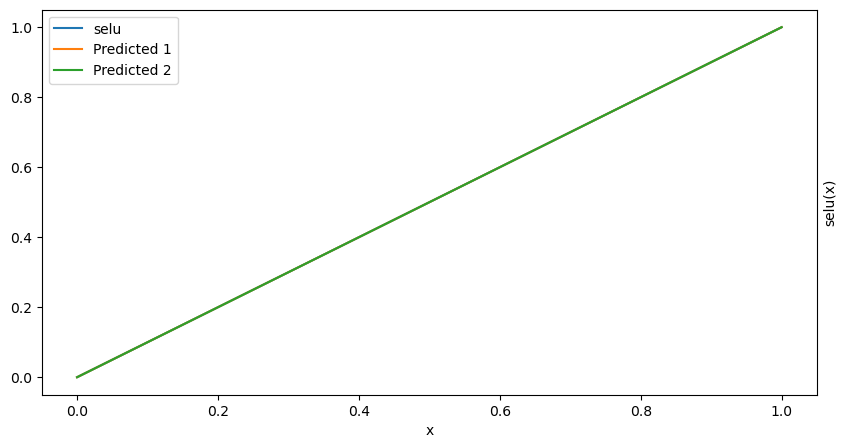

In [50]:
info()

Initial loss: 4.144e-15
gamma n° 2: 3.466e-01 -> Loss: 1.091e-15
gamma n° 3: 6.933e-01 -> Loss: 0.000e+00
gamma n° 4: 1.387e+00 -> Loss: 0.000e+00
Selected gamma: 6.933e-01, new loss: 0.000e+00
Improvement: 4.144e-15, fo improvement: 1.658e-14


  0%|          | 0/100 [00:00<?, ?it/s]

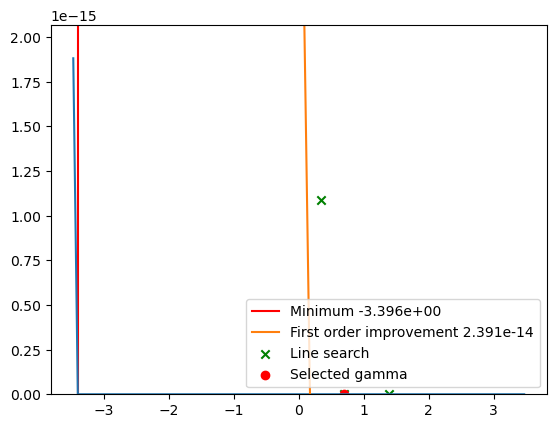

In [51]:
step()

Loss: 6.721e-16
LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=2, out_features=4, use_bias=False)
Min: -0.00030888756737113, Max: 1.4870471954345703
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=4, out_features=2, use_bias=False)
Min: -0.3819214999675751, Max: 1.0


LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=2, out_features=4, use_bias=False)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=4, out_features=2, use_bias=False)

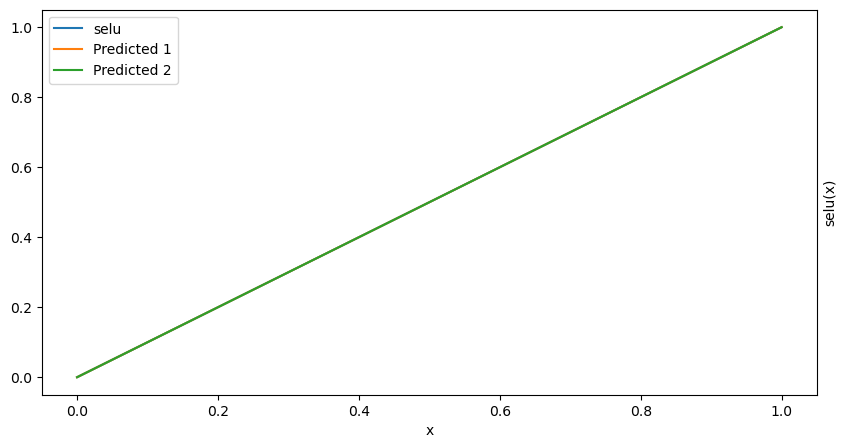

In [52]:
info()

# Fixed size, natural gradient

In [53]:
def plot():
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    plt_model(model, ax)

In [54]:
def step(show=True, selected_layer=None):

    # train_dataloader, val_dataloader, test_dataloader, _ = get_dataloaders(dataset_name="sin", batch_size=batch_size, split_train_val=0.3)
    id_dataloader = IdDataloader(nb_sample=nb_sample, batch_size=batch_size)
    initial_loss, _ = compute_statistics(
        growing_model=model,
        loss_function=nn.MSELoss(reduction="sum"),
        dataloader=id_dataloader,
    )

    print(f"Initial loss: {initial_loss:.3e}")

    model.compute_optimal_updates()
    model.reset_computation()
    if selected_layer is None:
        model.select_best_update()
    else:
        model.select_update(selected_layer)
    model.currently_updated_layer.extended_input_layer = None
    model.currently_updated_layer.previous_module.extended_output_layer = None
    model.currently_updated_layer.eigenvalue_extension = None

    selected_gamma, estimated_loss, x_sup, y_sup = line_search(
        model=model,
        loss_function=loss_func_sum,
        dataloader=id_dataloader,
        initial_loss=initial_loss,
        first_order_improvement=model.currently_updated_layer.first_order_improvement,
        verbose=show,
    )
    x_sup = np.array(x_sup)
    y_sup = np.array(y_sup)
    print(f"Selected gamma: {selected_gamma:.3e}, new loss: {estimated_loss:.3e}")
    print(
        f"Improvement: {initial_loss - estimated_loss:.3e}, fo improvement: {selected_gamma * model.currently_updated_layer.first_order_improvement.item():.3e}"
    )

    if show:
        window = 5 * selected_gamma
        x, y = full_search(
            model=model,
            loss=loss_func_sum,
            dataloader=id_dataloader,
            initial_loss=None,
            first_order_improvement=model.currently_updated_layer.first_order_improvement,
            min_value=-window,
            max_value=window,
        )

    model.amplitude_factor = np.sqrt(selected_gamma)
    model.apply_update()

    if show:
        x_min = x[np.argmin(y)]
        plt.axvline(x_min, color="red", label=f"Minimum {x_min:.3e}")
        plt.plot(x, y)
        plt.plot(
            x,
            -x * model.currently_updated_layer.first_order_improvement.item()
            + initial_loss,
            label=f"First order improvement {model.currently_updated_layer.first_order_improvement.item():.3e}",
        )
        selected_sup = x_sup < window
        plt.scatter(
            x_sup[selected_sup],
            y_sup[selected_sup],
            color="green",
            label="Line search",
            marker="x",
        )
        plt.scatter(selected_gamma, estimated_loss, color="red", label="Selected gamma")
        plt.ylim(0, 1.1 * max(y))
        plt.legend()

    # model.currently_updated_layer.delete_update()

In [55]:
def info():
    loss, _ = evaluate_model(
        model=model,
        dataloader=get_dataloaders(
            dataset_name="sin", batch_size=batch_size, split_train_val=0.3
        )[2],
        loss_function=nn.MSELoss(reduction="mean"),
    )
    print(f"Loss: {loss:.3e}")
    plot()
    for lay in model.layers:
        print(lay)
        # print(lay.weight)
        print(f"Min: {lay.weight.min().item()}, Max: {lay.weight.max().item()}")
    return model

In [56]:
batch_size = 1_000
nb_sample = 100
model = GrowingMLP(
    in_features=1,
    out_features=1,
    number_hidden_layers=5,
    hidden_size=1,
    activation=nn.SELU(),
)
model

LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=5, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=5, out_features=1, use_bias=True)

Loss: 8.662e-01
LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=5, use_bias=True)
Min: -0.684178352355957, Max: 0.9856066703796387
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=5, out_features=1, use_bias=True)
Min: -0.3411656618118286, Max: 0.2341030240058899


LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=5, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=5, out_features=1, use_bias=True)

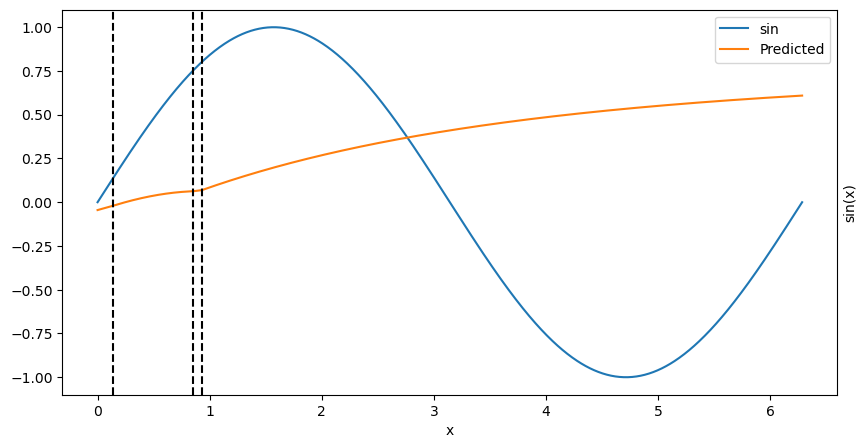

In [57]:
info()

In [58]:
step()

RuntimeError: mat1 and mat2 shapes cannot be multiplied (100x2 and 1x5)

Loss: 3.472e-01
LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=5, use_bias=True)
Min: -0.5791729092597961, Max: 0.4794309139251709
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=5, out_features=1, use_bias=True)
Min: -14.992019653320312, Max: 56.301029205322266


LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=5, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=5, out_features=1, use_bias=True)

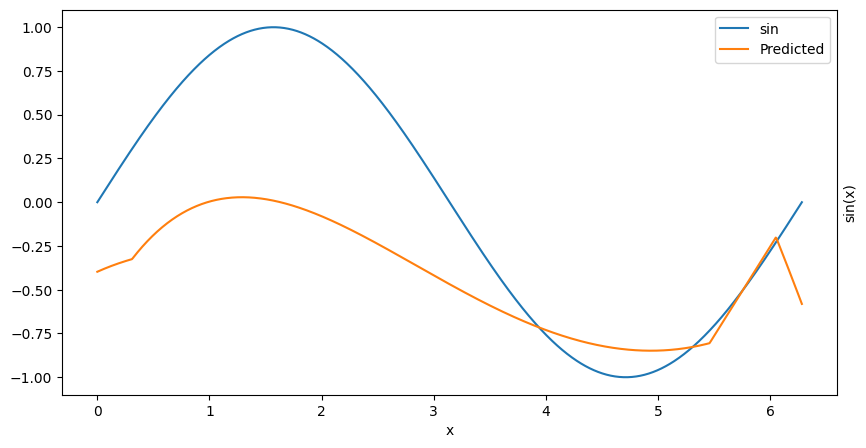

In [14]:
info()

Initial loss: 3.472e-01
Layer 0 update: 6394.11328125
Layer 0 parameter improvement: 6394.11328125
Layer 0 eigenvalues extension: None
Layer 1 update: 1.3314857482910156
Layer 1 parameter improvement: 1.3314857482910156
Layer 1 eigenvalues extension: None
Deleting layer 1
gamma: 5.430e-05 -> Loss: 1.054e-01
Selected gamma: 5.430e-05, new loss: 1.054e-01
Improvement: 2.418e-01, fo improvement: 3.472e-01


  0%|          | 0/100 [00:00<?, ?it/s]

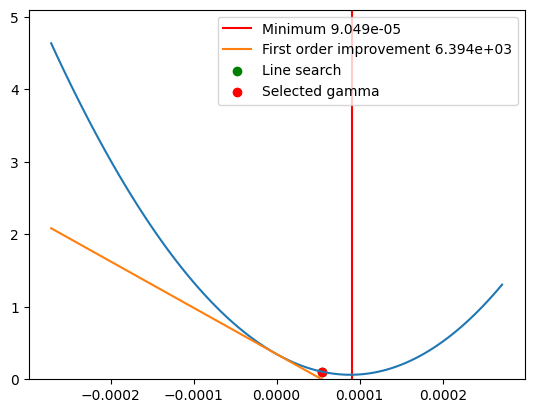

In [15]:
step()

Loss: 1.054e-01
LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=5, use_bias=True)
Min: -0.5791396498680115, Max: 0.4797440767288208
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=5, out_features=1, use_bias=True)
Min: -14.992019653320312, Max: 56.301029205322266


LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=5, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=5, out_features=1, use_bias=True)

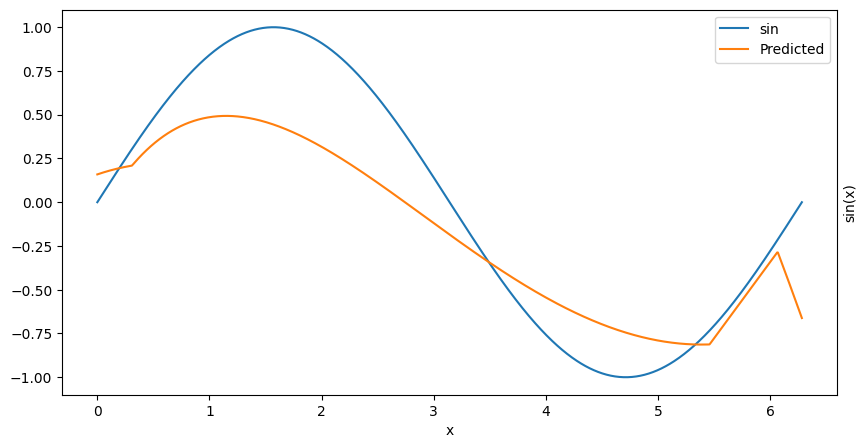

In [16]:
info()

Initial loss: 1.054e-01
Layer 0 update: 990.09521484375
Layer 0 parameter improvement: 990.09521484375
Layer 0 eigenvalues extension: None
Layer 1 update: 0.36208057403564453
Layer 1 parameter improvement: 0.36208057403564453
Layer 1 eigenvalues extension: None
Deleting layer 1
gamma: 1.065e-04 -> Loss: 6.308e-02
Selected gamma: 1.065e-04, new loss: 6.308e-02
Improvement: 4.234e-02, fo improvement: 1.054e-01


  0%|          | 0/100 [00:00<?, ?it/s]

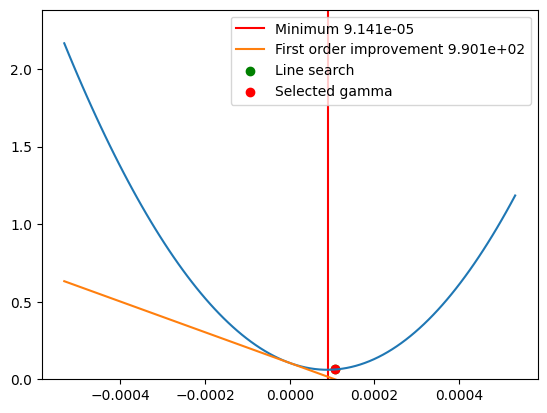

In [17]:
step()

Initial loss: 6.308e-02
Layer 0 update: 40.71656036376953
Layer 0 parameter improvement: 40.71656036376953
Layer 0 eigenvalues extension: None
Layer 1 update: 0.20148050785064697
Layer 1 parameter improvement: 0.20148050785064697
Layer 1 eigenvalues extension: None
Deleting layer 1
gamma: 1.549e-03 -> Loss: 5.451e-01
gamma: 7.746e-04 -> Loss: 1.686e-01
gamma: 3.873e-04 -> Loss: 8.168e-02
gamma: 1.936e-04 -> Loss: 6.380e-02
gamma: 9.682e-05 -> Loss: 6.129e-02
Selected gamma: 9.682e-05, new loss: 6.129e-02
Improvement: 1.789e-03, fo improvement: 3.942e-03


  0%|          | 0/100 [00:00<?, ?it/s]

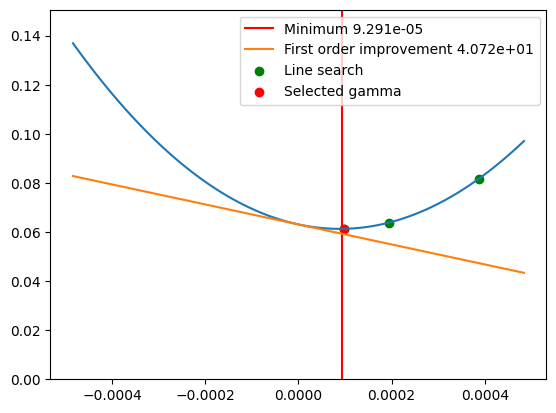

In [18]:
step()

Loss: 6.129e-02
LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=5, use_bias=True)
Min: -0.5791258215904236, Max: 0.4799354374408722
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=5, out_features=1, use_bias=True)
Min: -14.992019653320312, Max: 56.301029205322266


LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=5, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=5, out_features=1, use_bias=True)

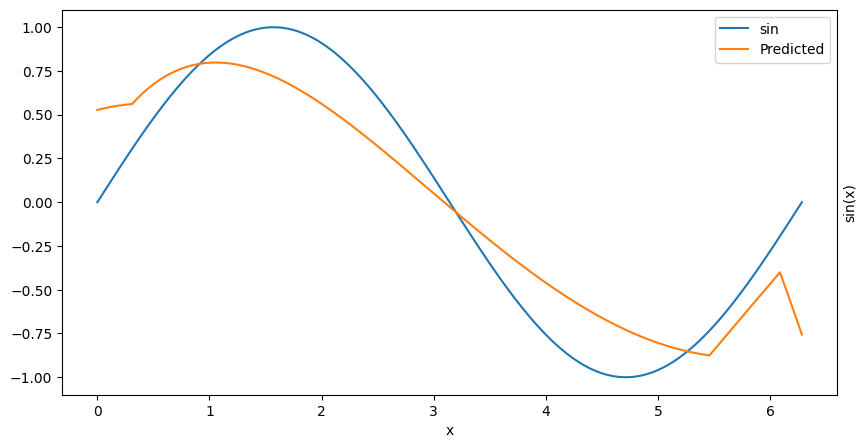

In [19]:
info()

Initial loss: 6.129e-02
Layer 0 update: 1.2565666437149048
Layer 0 parameter improvement: 1.2565666437149048
Layer 0 eigenvalues extension: None
Layer 1 update: 0.19372892379760742
Layer 1 parameter improvement: 0.19372892379760742
Layer 1 eigenvalues extension: None
Deleting layer 1
gamma: 4.877e-02 -> Loss: 1.128e+01
gamma: 2.439e-02 -> Loss: 2.824e+00
gamma: 1.219e-02 -> Loss: 7.409e-01
gamma: 6.097e-03 -> Loss: 2.269e-01
gamma: 3.048e-03 -> Loss: 1.007e-01
gamma: 1.524e-03 -> Loss: 7.018e-02
gamma: 7.621e-04 -> Loss: 6.303e-02
gamma: 3.810e-04 -> Loss: 6.148e-02
gamma: 1.905e-04 -> Loss: 6.122e-02
Selected gamma: 1.905e-04, new loss: 6.122e-02
Improvement: 7.065e-05, fo improvement: 2.394e-04


  0%|          | 0/100 [00:00<?, ?it/s]

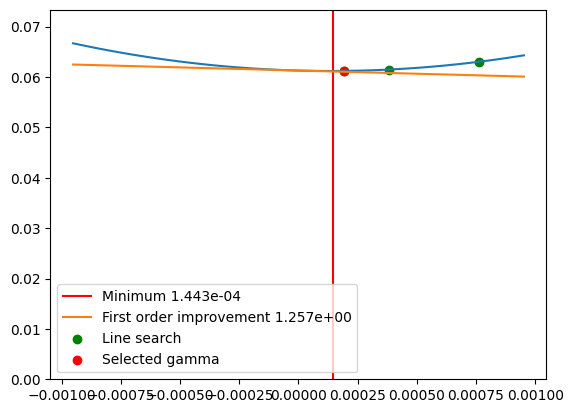

In [20]:
step()

Initial loss: 6.122e-02
Layer 0 update: 2.482269763946533
Layer 0 parameter improvement: 2.482269763946533
Layer 0 eigenvalues extension: None
Layer 1 update: 0.1924634724855423
Layer 1 parameter improvement: 0.1924634724855423
Layer 1 eigenvalues extension: None
Deleting layer 1
gamma: 2.466e-02 -> Loss: 8.815e+00
gamma: 1.233e-02 -> Loss: 2.274e+00
gamma: 6.165e-03 -> Loss: 6.064e-01
gamma: 3.083e-03 -> Loss: 1.923e-01
gamma: 1.541e-03 -> Loss: 9.191e-02
gamma: 7.707e-04 -> Loss: 6.791e-02
gamma: 3.853e-04 -> Loss: 6.241e-02
gamma: 1.927e-04 -> Loss: 6.127e-02
gamma: 9.633e-05 -> Loss: 6.111e-02
Selected gamma: 9.633e-05, new loss: 6.111e-02
Improvement: 1.051e-04, fo improvement: 2.391e-04


  0%|          | 0/100 [00:00<?, ?it/s]

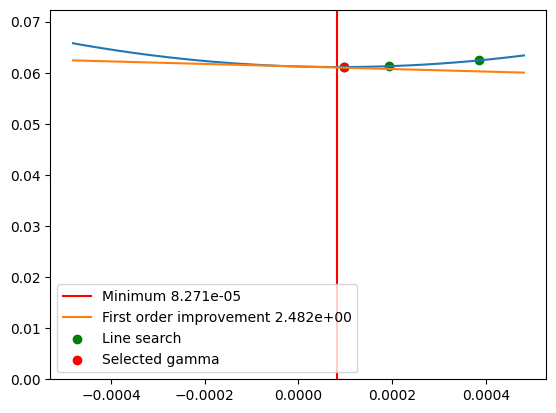

In [21]:
step()

Loss: 6.111e-02
LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=5, use_bias=True)
Min: -0.579138457775116, Max: 0.4798868000507355
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=5, out_features=1, use_bias=True)
Min: -14.992019653320312, Max: 56.301029205322266


LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=5, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=5, out_features=1, use_bias=True)

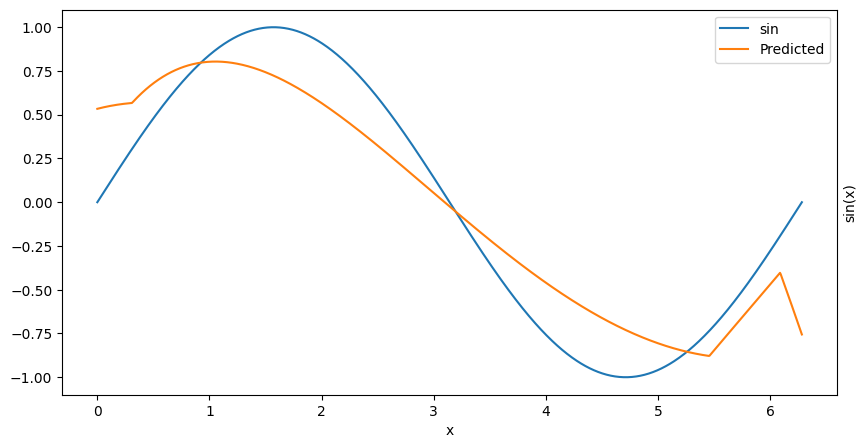

In [22]:
info()

In [23]:
for _ in range(10):
    step(show=False)

Initial loss: 6.111e-02
Selected gamma: 2.256e-04, new loss: 6.108e-02
Improvement: 3.532e-05, fo improvement: 2.387e-04
Initial loss: 6.108e-02
Selected gamma: 1.158e-04, new loss: 6.099e-02
Improvement: 8.489e-05, fo improvement: 4.772e-04
Initial loss: 6.099e-02
Selected gamma: 6.806e-05, new loss: 6.086e-02
Improvement: 1.258e-04, fo improvement: 2.382e-04
Initial loss: 6.086e-02
Selected gamma: 7.799e-04, new loss: 6.063e-02
Improvement: 2.368e-04, fo improvement: 4.755e-04
Initial loss: 6.063e-02
Selected gamma: 6.612e-05, new loss: 6.039e-02
Improvement: 2.345e-04, fo improvement: 4.737e-04
Initial loss: 6.039e-02
Selected gamma: 7.830e-04, new loss: 6.022e-02
Improvement: 1.738e-04, fo improvement: 4.718e-04
Initial loss: 6.022e-02
Selected gamma: 1.067e-04, new loss: 6.006e-02
Improvement: 1.615e-04, fo improvement: 9.409e-04
Initial loss: 6.006e-02
Selected gamma: 8.767e-05, new loss: 5.990e-02
Improvement: 1.626e-04, fo improvement: 4.692e-04
Initial loss: 5.990e-02
Selected

Loss: 5.975e-02
LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=5, use_bias=True)
Min: -0.5792499780654907, Max: 0.479442834854126
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=5, out_features=1, use_bias=True)
Min: -14.992019653320312, Max: 56.301029205322266


LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=5, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=5, out_features=1, use_bias=True)

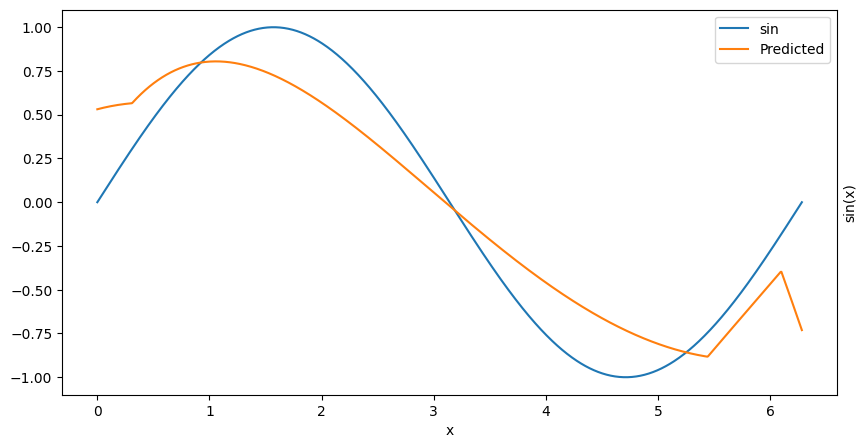

In [24]:
info()

Initial loss: 5.975e-02
Layer 0 update: 0.7542245984077454
Layer 0 parameter improvement: 0.7542245984077454
Layer 0 eigenvalues extension: None
Deleting layer 0
Layer 1 update: 0.19547200202941895
Layer 1 parameter improvement: 0.19547200202941895
Layer 1 eigenvalues extension: None
gamma: 3.057e-01 -> Loss: 1.867e-02
Selected gamma: 3.057e-01, new loss: 1.867e-02
Improvement: 4.108e-02, fo improvement: 5.975e-02


  0%|          | 0/100 [00:00<?, ?it/s]

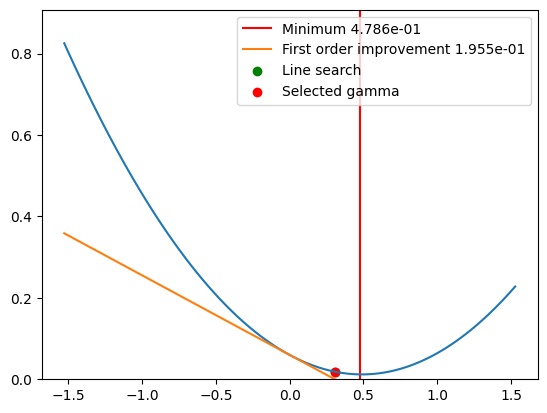

In [25]:
step(selected_layer=1)

Loss: 1.867e-02
LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=5, use_bias=True)
Min: -0.5792499780654907, Max: 0.479442834854126
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=5, out_features=1, use_bias=True)
Min: -25.312850952148438, Max: 102.03551483154297


LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=5, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=5, out_features=1, use_bias=True)

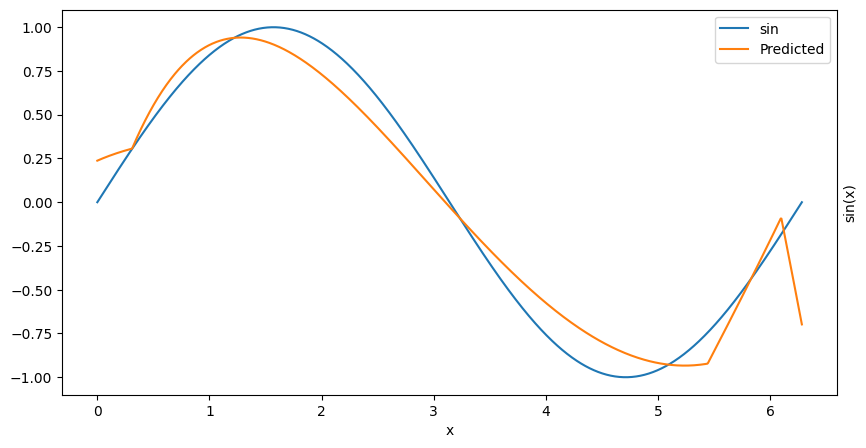

In [26]:
info()

Initial loss: 1.867e-02
Layer 0 update: 0.6999372839927673
Layer 0 parameter improvement: 0.6999372839927673
Layer 0 eigenvalues extension: None
Layer 1 update: 0.027507111430168152
Layer 1 parameter improvement: 0.027507111430168152
Layer 1 eigenvalues extension: None
Deleting layer 1
gamma: 2.668e-02 -> Loss: 7.435e+00
gamma: 1.334e-02 -> Loss: 1.865e+00
gamma: 6.670e-03 -> Loss: 4.670e-01
gamma: 3.335e-03 -> Loss: 1.276e-01
gamma: 1.668e-03 -> Loss: 4.506e-02
gamma: 8.338e-04 -> Loss: 2.495e-02
gamma: 4.169e-04 -> Loss: 2.009e-02
gamma: 2.084e-04 -> Loss: 1.896e-02
gamma: 1.042e-04 -> Loss: 1.871e-02
gamma: 5.211e-05 -> Loss: 1.866e-02
Selected gamma: 5.211e-05, new loss: 1.866e-02
Improvement: 9.783e-06, fo improvement: 3.647e-05


  0%|          | 0/100 [00:00<?, ?it/s]

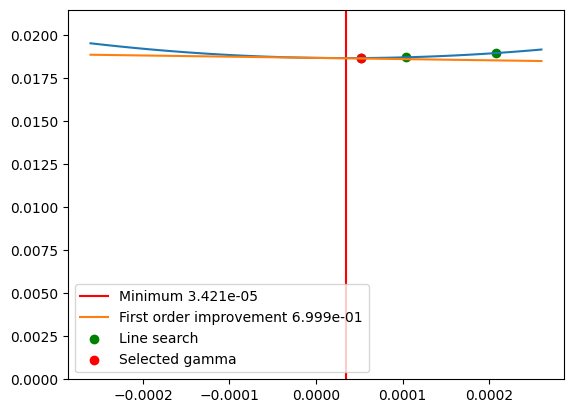

In [27]:
step()

Initial loss: 1.866e-02
Layer 0 update: 1.4002584218978882
Layer 0 parameter improvement: 1.4002584218978882
Layer 0 eigenvalues extension: None
Deleting layer 0
Layer 1 update: 0.02719402313232422
Layer 1 parameter improvement: 0.02719402313232422
Layer 1 eigenvalues extension: None
gamma: 6.864e-01 -> Loss: 1.281e-02
Selected gamma: 6.864e-01, new loss: 1.281e-02
Improvement: 5.851e-03, fo improvement: 1.866e-02


  0%|          | 0/100 [00:00<?, ?it/s]

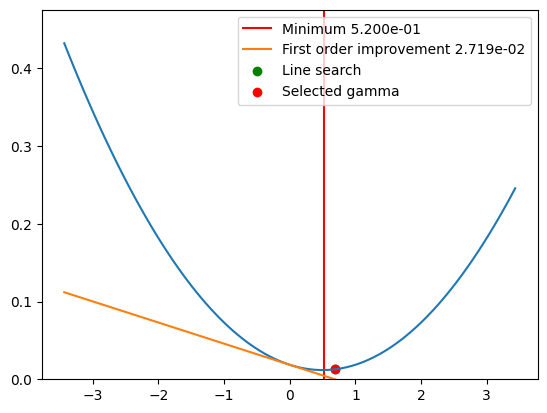

In [28]:
step(selected_layer=1)

Loss: 1.281e-02
LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=5, use_bias=True)
Min: -0.5792522430419922, Max: 0.4794358015060425
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=5, out_features=1, use_bias=True)
Min: -33.651790618896484, Max: 138.26840209960938


LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=5, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=5, out_features=1, use_bias=True)

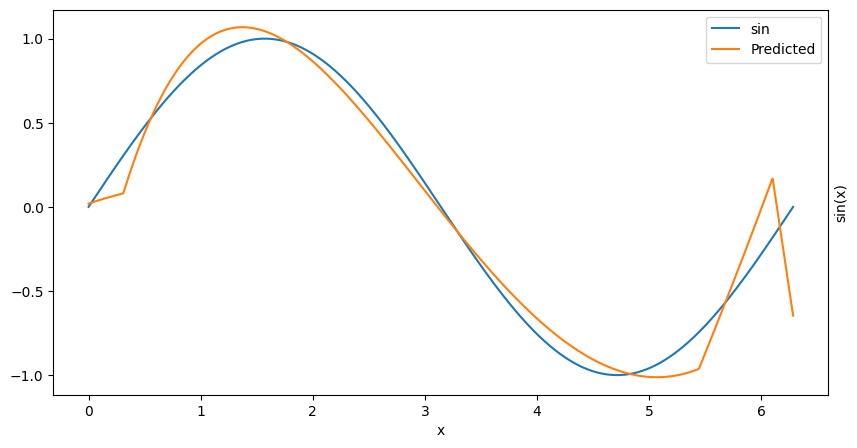

In [29]:
info()

# Fixed size MLP

In [22]:
nb_epoch = 100
batch_size = 1_000
nb_sample = 1_000

In [23]:
hidden_size = 1
seed = torch.randint(0, 1000, (1,)).item()
print(f"Seed: {seed}")
torch.manual_seed(seed)
l1 = nn.Linear(1, hidden_size, device=DEVICE)
l2 = nn.Linear(hidden_size, 1, device=DEVICE)
model = nn.Sequential(l1, nn.ReLU(), l2)

Seed: 44


In [88]:
l1.weight.data = torch.ones_like(l1.weight.data)
# a = np.pi / 4
# b = 1.
i = np.pi
j = 0
a_1 = -3 / np.pi**2
a_2 = -3 / np.pi**2

l1.bias.data = -torch.tensor([0, i], device=DEVICE)
l2.weight.data = torch.tensor([[a_1, a_2 - a_1]], device=DEVICE)
l2.bias.data = torch.tensor([j - a_1 * i], device=DEVICE)

In [18]:
l1.weight.data = torch.ones_like(l1.weight.data)
# a = np.pi / 4
# b = 1.
c = 0.651259030623100
a = -0.378951509815716
i = 1.636

l1.bias.data = -torch.tensor([i], device=DEVICE)
l2.weight.data = torch.tensor([[a]], device=DEVICE)
l2.bias.data = torch.tensor([c], device=DEVICE)

Initial error: 1.59e-01


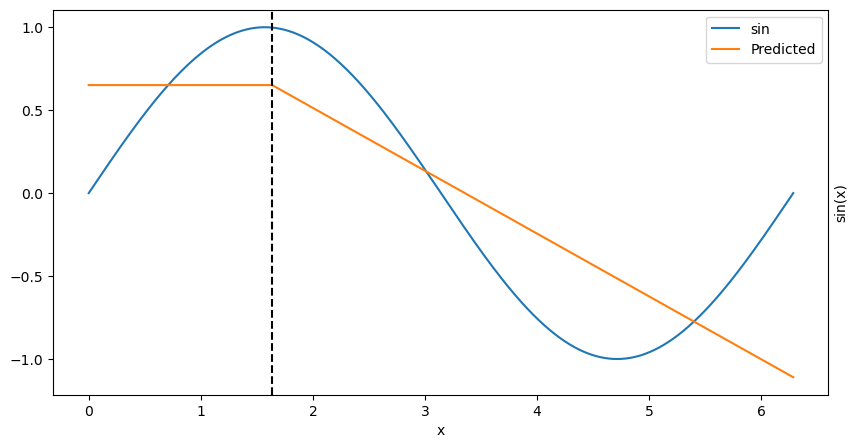

In [19]:
l2_err = evaluate_model(
    model, SinDataloader(nb_sample=nb_sample, batch_size=batch_size), AxisMSELoss()
)[0]
print(f"Initial error: {l2_err:.2e}")
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plt_model(model, ax)

In [24]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)


res = train(
    model=model,
    train_dataloader=SinDataloader(batch_size=batch_size, nb_sample=nb_sample),
    nb_epoch=10,
    optimizer=optimizer,
    show=True,
)[0]

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 0:	 Train: loss=5.082e-01, accuracy=0.00	 
Epoch 1:	 Train: loss=5.002e-01, accuracy=0.00	 
Epoch 2:	 Train: loss=5.002e-01, accuracy=0.00	 
Epoch 3:	 Train: loss=5.002e-01, accuracy=0.00	 
Epoch 4:	 Train: loss=5.002e-01, accuracy=0.00	 
Epoch 5:	 Train: loss=5.002e-01, accuracy=0.00	 
Epoch 6:	 Train: loss=5.002e-01, accuracy=0.00	 
Epoch 7:	 Train: loss=5.002e-01, accuracy=0.00	 
Epoch 8:	 Train: loss=5.002e-01, accuracy=0.00	 
Epoch 9:	 Train: loss=5.002e-01, accuracy=0.00	 


Initial error: 5.00e-01


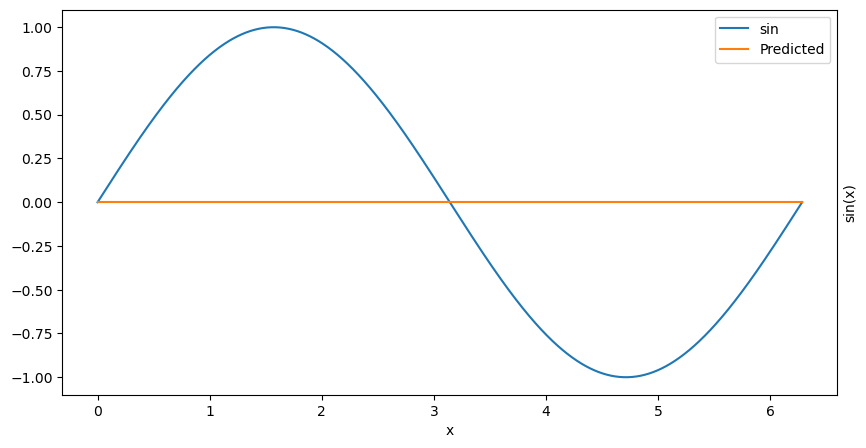

In [25]:
l2_err = evaluate_model(
    model, SinDataloader(nb_sample=nb_sample, batch_size=batch_size), AxisMSELoss()
)[0]
print(f"Initial error: {l2_err:.2e}")
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plt_model(model, ax)

Initial error: 1.59e-01


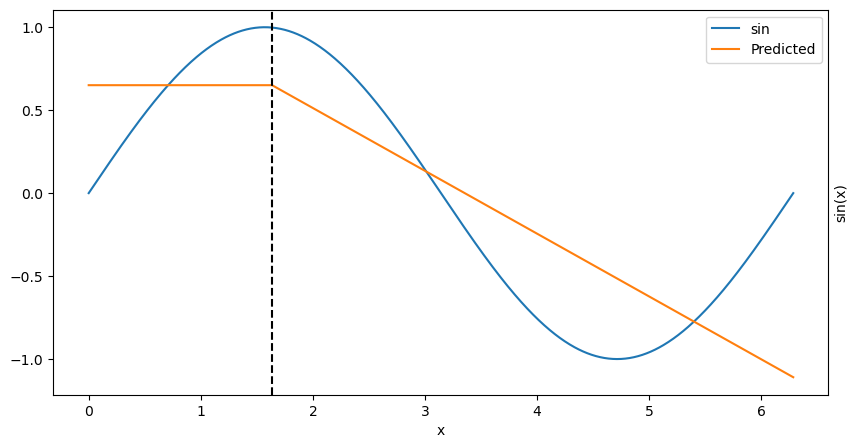

In [ ]:
l2_err = evaluate_model(
    model, SinDataloader(nb_sample=nb_sample, batch_size=batch_size), AxisMSELoss()
)[0]
print(f"Initial error: {l2_err:.2e}")
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plt_model(model, ax)

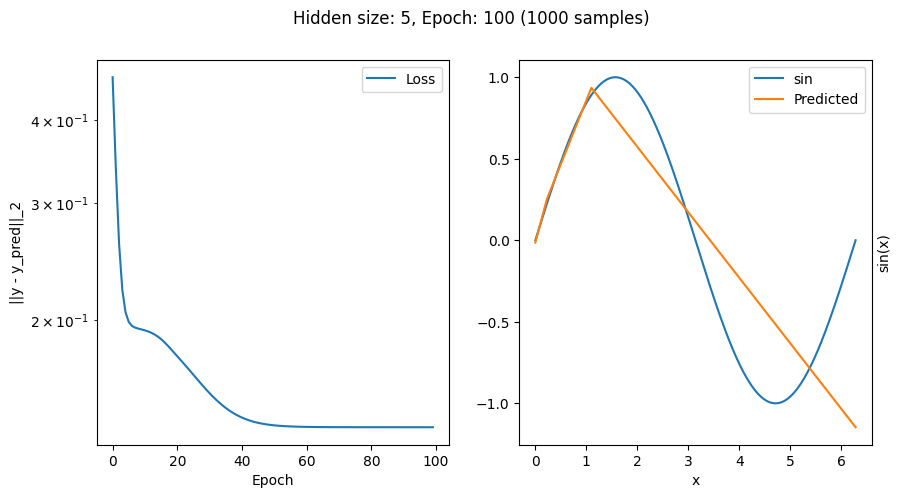

In [55]:
# plot the loss and the model on [0, 1]
# plt.title(f"Hidden size: {hidden_size}")
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# put a title on the figure
fig.suptitle(f"Hidden size: {hidden_size}, Epoch: {nb_epoch} ({nb_sample} samples)")

ax[0].plot(res, label="Loss")
ax[0].legend()
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("||y - y_pred||_2")
ax[0].set_yscale("log")

x = torch.linspace(0, 2 * np.pi, 1000, device=DEVICE).view(-1, 1)
y = torch.sin(x)
y_pred = model(x)
ax[1].plot(x.cpu().numpy(), y.cpu().numpy(), label="sin")
ax[1].plot(x.cpu().numpy(), y_pred.cpu().detach().numpy(), label="Predicted")
ax[1].legend()
ax[1].set_xlabel("x")
ax[1].yaxis.set_label_position("right")
ax[1].set_ylabel("sin(x)")
plt.show()

In [38]:
hidden_size = 100
model = GrowingMLP(1, 1, hidden_size, 2, activation=nn.SELU())
model

LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=100, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=100, out_features=100, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=100, out_features=1, use_bias=True)

In [58]:
for epoch in range(nb_epoch):
    res = train(
        model=model,
        train_dataloader=get_dataloaders(dataset_name="sin", batch_size=batch_size),
        optimizer=torch.optim.SGD(model.parameters(), lr=1e-3),
        loss_function=nn.MSELoss(),
        show=True,
    )
print(res)

NameError: name 'nb_epoch' is not defined

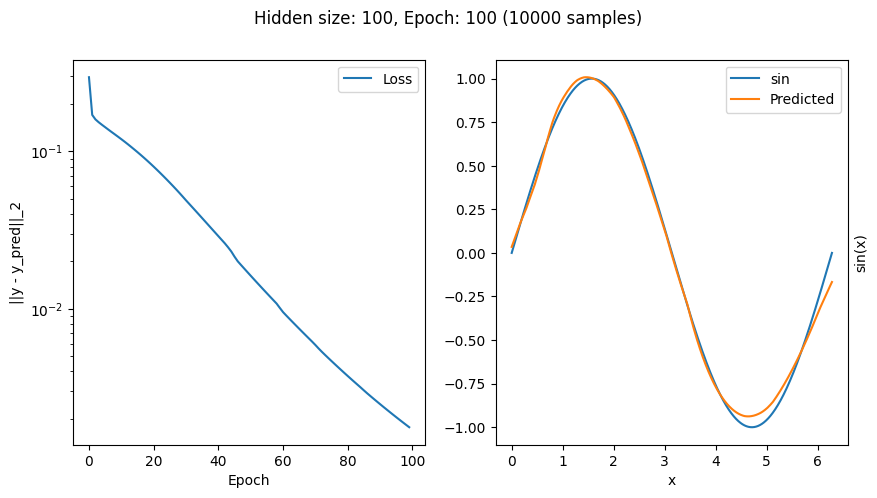

In [43]:
# plot the loss and the model on [0, 1]
# plt.title(f"Hidden size: {hidden_size}")
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# put a title on the figure
fig.suptitle(f"Hidden size: {hidden_size}, Epoch: {nb_epoch} ({nb_samples} samples)")

ax[0].plot(res, label="Loss")
ax[0].legend()
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("||y - y_pred||_2")
ax[0].set_yscale("log")

x = torch.linspace(0, 2 * np.pi, 1000, device=DEVICE).view(-1, 1)
y = torch.sin(x)
y_pred = model(x)
ax[1].plot(x.cpu().numpy(), y.cpu().numpy(), label="sin")
ax[1].plot(x.cpu().numpy(), y_pred.cpu().detach().numpy(), label="Predicted")
ax[1].legend()
ax[1].set_xlabel("x")
ax[1].yaxis.set_label_position("right")
ax[1].set_ylabel("sin(x)")
plt.show()

In [45]:
hidden_size = 10
model = GrowingMLP(1, 1, hidden_size, 2, activation=nn.SELU())
model

LinearGrowingModule(LinearGrowingModule(Layer 0))(in_features=1, out_features=10, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 1))(in_features=10, out_features=10, use_bias=True)
LinearGrowingModule(LinearGrowingModule(Layer 2))(in_features=10, out_features=1, use_bias=True)

In [46]:
res = train(
    model=model,
    train_dataloader=SinDataloader(batch_size=batch_size, nb_sample=nb_sample),
    nb_epoch=nb_epoch,
    optimizer=torch.optim.SGD(model.parameters(), lr=1e-3),
    show=True,
)[0]

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 0:	 Train: loss=5.449e-01, accuracy=0.00	 
Epoch 10:	 Train: loss=1.826e-01, accuracy=0.00	 
Epoch 20:	 Train: loss=1.726e-01, accuracy=0.00	 
Epoch 30:	 Train: loss=1.631e-01, accuracy=0.00	 
Epoch 40:	 Train: loss=1.537e-01, accuracy=0.00	 
Epoch 50:	 Train: loss=1.454e-01, accuracy=0.00	 
Epoch 60:	 Train: loss=1.383e-01, accuracy=0.00	 
Epoch 70:	 Train: loss=1.314e-01, accuracy=0.00	 
Epoch 80:	 Train: loss=1.240e-01, accuracy=0.00	 
Epoch 90:	 Train: loss=1.162e-01, accuracy=0.00	 


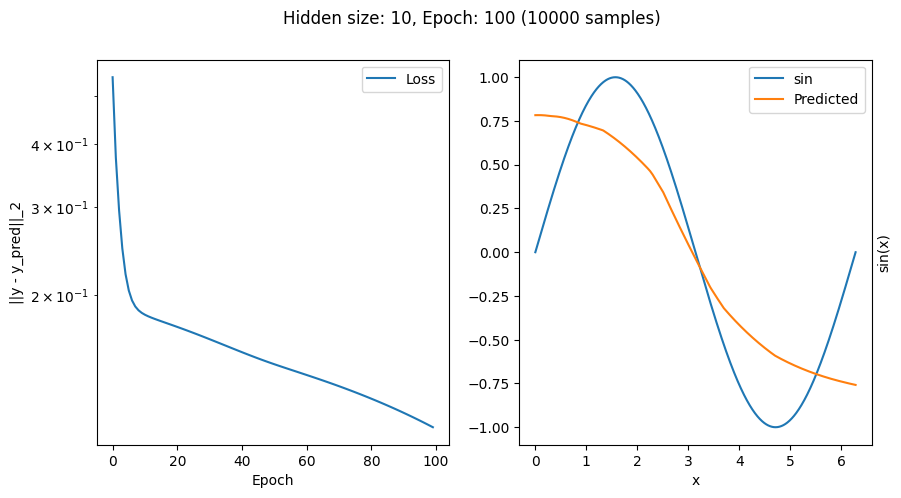

In [47]:
# plot the loss and the model on [0, 1]
# plt.title(f"Hidden size: {hidden_size}")
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# put a title on the figure
fig.suptitle(f"Hidden size: {hidden_size}, Epoch: {nb_epoch} ({nb_samples} samples)")

ax[0].plot(res, label="Loss")
ax[0].legend()
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("||y - y_pred||_2")
ax[0].set_yscale("log")

x = torch.linspace(0, 2 * np.pi, 1000, device=DEVICE).view(-1, 1)
y = torch.sin(x)
y_pred = model(x)
ax[1].plot(x.cpu().numpy(), y.cpu().numpy(), label="sin")
ax[1].plot(x.cpu().numpy(), y_pred.cpu().detach().numpy(), label="Predicted")
ax[1].legend()
ax[1].set_xlabel("x")
ax[1].yaxis.set_label_position("right")
ax[1].set_ylabel("sin(x)")
plt.show()

NameError: name 'res' is not defined

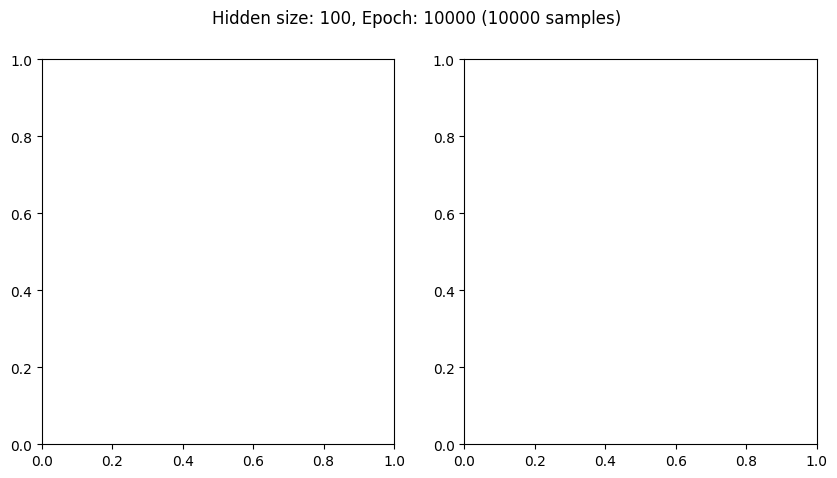

In [32]:
# plot the loss and the model on [0, 1]
# plt.title(f"Hidden size: {hidden_size}")
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# put a title on the figure
fig.suptitle(f"Hidden size: {hidden_size}, Epoch: {nb_epoch} ({nb_samples} samples)")

ax[0].plot(res, label="Loss")
ax[0].legend()
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("||y - y_pred||_2")
ax[0].set_yscale("log")

x = torch.linspace(0, 2 * np.pi, 1000, device=DEVICE).view(-1, 1)
y = torch.sin(x)
y_pred = model(x)
ax[1].plot(x.cpu().numpy(), y.cpu().numpy(), label="sin")
ax[1].plot(x.cpu().numpy(), y_pred.cpu().detach().numpy(), label="Predicted")
ax[1].legend()
ax[1].set_xlabel("x")
ax[1].yaxis.set_label_position("right")
ax[1].set_ylabel("sin(x)")
plt.show()